# Çapraz Hedef: İkinci El / Yeni Araç Satış Oranı — `target_capraz_ikinciel_yeniarac_satis_orani` (AutoGluon TimeSeries)

Bu defter, piyasadaki ikinci-el devir hacminin yeni araç (ODMD) satış hacmine oranını bir ay
ilerisi için tahmin eden rolling-origin backtest çalışmasını uçtan uca üretir ve doğrular.

Diğer üç hedeften (`target_betam_dom_gun`, `target_indicata_satis_hizi_gun`,
`target_indicata_satis_ilan_orani_pct`: ham kolonun birebir kopyası) ve
`target_quickfinans_dom_gun`'dan (tamamen harici bir dosyadan okunur) farklı olarak, bu hedef
üçüncü bir mekanizmadan geliyor: `hiz_target_backtest_pipeline.py` içindeki
`DERIVED_TARGET_FORMULAS` sözlüğü — harici hiçbir kaynağa ihtiyaç duymadan,
**`feature_master_aylik.csv` içinde zaten var olan iki ham kolonun matematiksel oranı** olarak
anında ("çapraz") hesaplanır:

\[
\text{target\_capraz\_ikinciel\_yeniarac\_satis\_orani}_t =
\frac{\text{noter\_devir\_otomobil\_adet}_t}{\text{odmd\_otomobil\_adet}_t}
\]

- `noter_devir_otomobil_adet`: o ay noterde el değiştiren otomobil (ikinci el devir) adedi
- `odmd_otomobil_adet`: o ay ODMD (Otomotiv Distribütörleri Derneği) raporuna göre yurt içi
  perakende satılan sıfır km otomobil adedi

Oran, piyasadaki ikinci-el / yeni-araç satış dengesinin bir göstergesidir — değer arttıkça ikinci
el devir hacmi yeni araç satışlarına göre büyüyor demektir (ör. yeni araç arzının daraldığı veya
fiyatların talebi ikinci-el'e kaydırdığı dönemlerde). Formülün her iki kaynak kolonu da
(`noter_devir_otomobil_adet`, `odmd_otomobil_adet`) kendi-kaynak sızıntı riski taşıdığından
feature listesinden dışlanır (bkz. Bölüm 2).

- Veri: 101 gözlem, 2018-01 → 2026-05
- AutoGluon ayarı: `medium_quality`, fold başına `time_limit=45sn`
- Tahmin ufku: 1 ay (`prediction_length=1`)
- Backtest: son 6 ay (2025-12, 2026-01, 2026-02, 2026-03, 2026-04, 2026-05) — rolling-origin /
  genişleyen pencere — her test ayı yalnız kendinden önceki gerçek verilerle sıfırdan eğitilen
  ayrı bir modelle tahmin edilir
- Referans: "geçen yılın aynı ayı" (t-12) naive baseline

## 1. Kütüphaneler ve sabitler

Bu notebook proje kökünden veya `notebooks/` klasöründen açılabilir; `.venv-ag` ortamını gerektirir.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

FEATURE_PATH = ROOT / "data" / "target_bazli_birlesik_setler" / "feature_master_aylik.csv"
OUT_DIR = ROOT / "outputs" / "hiz_target_backtest" / "target_capraz_ikinciel_yeniarac_satis_orani"

TARGET = "target_capraz_ikinciel_yeniarac_satis_orani"
DATE_COL = "referans_ayi"
KAYNAK_KOLONLAR = ["noter_devir_otomobil_adet", "odmd_otomobil_adet"]

print("Proje kökü:", ROOT)
print("Hedef:", TARGET)

Proje kökü: C:\Users\YOGA\Desktop\araç piyasasında yön analizi için kullanılan yöntemler v2
Hedef: target_capraz_ikinciel_yeniarac_satis_orani


## 2. Sızıntısız feature tablosu kurma — iki kaynak kolonun birlikte dışlanması

`feature_master_aylik.csv`'deki tüm aylık feature'lar hedefe eklenir. `target_capraz_ikinciel_yeniarac_satis_orani`,
`DERIVED_TARGET_FORMULAS` mekanizmasıyla üretilen bir "çapraz" (türetilmiş) hedeftir: ne
`target_quickfinans_dom_gun` gibi harici bir dosyadan okunur, ne de `target_betam_dom_gun` gibi
`feature_master_aylik.csv`'de zaten hazır duran tek bir ham kolonun birebir kopyasıdır — bunun
yerine, dosyada zaten var olan **iki** ham kolonun oranı olarak anında hesaplanır. Bu yüzden tek
kaynaklı hedeflerdeki `TARGET_TO_SOURCE_COL` (kolon → tek isim) yerine `DERIVED_TARGET_FORMULAS`
sözlüğü kullanılır; her girdinin `kaynak_kolonlar` alanı bir **küme** (burada iki eleman) tutar.
Üç tür kolon dışlanır:

1. **Hedefin türetildiği HER İKİ ham kaynak kolon** (`noter_devir_otomobil_adet` VE
   `odmd_otomobil_adet`) — hedef bu iki kolonun matematiksel bir fonksiyonu olduğundan, ikisinden
   biri feature olarak kalsaydı dolaylı/doğrudan kopya sızıntısı olurdu.
2. **Genel sızıntı yasakları** (`modelleme_sizinti_kisitlari.csv`'nin `tum_targetlar` satırları):
   karışık aylık/yıllık reel değişim kolonu, ÖTV-en-yakın-olay farkı, audit kolonu.
3. **`indicata_*`/`arabam_*`/`betam_*` ailesinin aynı-ay versiyonları** — bu raporlar referans
   ayından sonra yayımlanıyor; bunun yerine 1 ay gecikmeli (`lag1`) türevleri kullanılır.

`build_feature_table`, `target_col` bir `DERIVED_TARGET_FORMULAS` anahtarıysa ilgili `func`'ı
(`_formul_ikinciel_yeniarac_satis_orani`) uygulayarak hedefi `feature_master_aylik.csv`'den türetir
ve `kaynak_kolonlar` kümesinin tamamını `excluded_self`'e ekler — aşağıdaki iki fonksiyon kodunda
görülebilir.

In [2]:
def _formul_ikinciel_yeniarac_satis_orani(fm: pd.DataFrame) -> pd.Series:
    return fm["noter_devir_otomobil_adet"] / fm["odmd_otomobil_adet"]

def build_feature_table(target_col: str) -> tuple[pd.DataFrame, list[str], dict]:
    fm = pd.read_csv(FEATURE_PATH)

    if target_col in DERIVED_TARGET_FORMULAS:
        # Hedef, feature_master_aylik.csv'deki VAR OLAN ham kolonlarin matematiksel
        # capraz-referanslanmasiyla (oran/fark/carpim) turetilir - hicbir harici kaynak
        # veya master veri seti gerekmez.
        spec = DERIVED_TARGET_FORMULAS[target_col]
        target_series = spec["func"](fm)
        mv = pd.DataFrame({DATE_COL: fm[DATE_COL], target_col: target_series})
    elif target_col in EXTERNAL_TARGET_SOURCES:
        # Bu hedefin ham kaynagi feature_master_aylik.csv / master veri setinde YOK -
        # ayri bir data/ klasorunden okunup referans_ayi uzerinden birlestirilir.
        src = EXTERNAL_TARGET_SOURCES[target_col]
        ext = pd.read_csv(src["csv"])[[src["date_col"], src["value_col"]]]
        ext = ext.rename(columns={src["date_col"]: DATE_COL, src["value_col"]: target_col})
        mv = ext
    else:
        mv = pd.read_csv(MASTER_PATH)[[DATE_COL, target_col]]

    df = fm.merge(mv, on=DATE_COL, how="left")
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)

    if target_col in DERIVED_TARGET_FORMULAS:
        excluded_self = set(DERIVED_TARGET_FORMULAS[target_col]["kaynak_kolonlar"])
    else:
        source_col = TARGET_TO_SOURCE_COL.get(target_col)
        excluded_self = {source_col} if source_col else set()
    excluded_hard = HARD_EXCLUDE_ALWAYS & set(df.columns)

    lagged_created = []
    raw_family_cols = [
        c for c in fm.columns
        if c != DATE_COL and c.startswith(LAGGED_FAMILY_PREFIXES) and c not in excluded_hard
    ]
    for col in raw_family_cols:
        lag_col = f"{col}_lag1"
        df[lag_col] = df[col].shift(1)
        lagged_created.append(lag_col)

    df["ay"] = df[DATE_COL].dt.month
    df["ceyrek"] = df[DATE_COL].dt.quarter
    df["sin_ay"] = np.sin(2 * np.pi * df["ay"] / 12.0)
    df["cos_ay"] = np.cos(2 * np.pi * df["ay"] / 12.0)
    calendar_cols = ["ay", "ceyrek", "sin_ay", "cos_ay"]

    drop_cols = excluded_self | excluded_hard | set(raw_family_cols)
    candidate_features = [
        c for c in df.columns
        if c not in drop_cols and c not in (DATE_COL, target_col) and c not in lagged_created
    ] + lagged_created + calendar_cols
    candidate_features = list(dict.fromkeys(candidate_features))  # sirali unique

    exclusion_log = {
        "hedefin_ham_kaynak_kolonu_disi": sorted(excluded_self),
        "genel_sizinti_yasaklari": sorted(excluded_hard),
        "ayni_ay_yerine_lag1_yapilan_aile_kolonlari": sorted(raw_family_cols),
    }
    return df, candidate_features, exclusion_log

## 3. Korelasyon filtresi — |Pearson| < 0.1 ele

`min_periods=12` (en az 12 örtüşen gözlem) şartıyla hedefle mutlak korelasyonu 0.1 altında olan
veya hesaplanamayan (NaN) feature'lar elenir.

In [3]:
def korelasyon_filtresi(df: pd.DataFrame, target_col: str, features: list[str]) -> tuple[list[str], pd.DataFrame]:
    sub = df.dropna(subset=[target_col])
    corr = sub[features + [target_col]].corr(min_periods=MIN_PERIODS)[target_col].drop(target_col)
    ozet = pd.DataFrame({
        "feature": corr.index,
        "korelasyon": corr.values,
        "karar": np.where(corr.abs() >= CORR_ESIK, "tutuldu", "elendi"),
    }).sort_values("korelasyon")
    tutulan = ozet.loc[ozet["karar"] == "tutuldu", "feature"].tolist()
    return tutulan, ozet

## 4. Çoklu-doğrusallık filtresi — |Pearson| > 0.9 ele

Kalan feature'lar arasında mutlak korelasyonu 0.9'u aşan çiftlerden target ile daha düşük
korelasyona sahip olan, union-find ile bulunan bağlı bileşen grupları üzerinden elenir.

In [4]:
def coklu_dogrusallik_azalt(df: pd.DataFrame, target_col: str, features: list[str]) -> tuple[list[str], pd.DataFrame]:
    sub = df.dropna(subset=[target_col])
    if len(features) < 2:
        return features, pd.DataFrame(columns=["feature_a", "feature_b", "korelasyon", "elenen"])

    hedef_korr = sub[features + [target_col]].corr(min_periods=MIN_PERIODS)[target_col].drop(target_col)
    feat_korr = sub[features].corr(min_periods=MIN_PERIODS)

    ebeveyn = {f: f for f in features}

    def bul(f):
        while ebeveyn[f] != f:
            f = ebeveyn[f]
        return f

    def birlestir(a, b):
        ra, rb = bul(a), bul(b)
        if ra != rb:
            ebeveyn[ra] = rb

    pair_rows = []
    for i, a in enumerate(features):
        for b in features[i + 1:]:
            v = feat_korr.loc[a, b]
            if pd.notna(v) and abs(v) > COLLIN_ESIK:
                birlestir(a, b)
                pair_rows.append({"feature_a": a, "feature_b": b, "korelasyon": v})

    gruplar: dict[str, list[str]] = {}
    for f in features:
        gruplar.setdefault(bul(f), []).append(f)

    tutulan = list(features)
    elenen_set = set()
    for grup in gruplar.values():
        if len(grup) < 2:
            continue
        skorlu = [(f, abs(hedef_korr.get(f, np.nan))) for f in grup]
        skorlu = [(f, s if pd.notna(s) else -1.0) for f, s in skorlu]
        en_iyi = max(skorlu, key=lambda x: x[1])[0]
        for f in grup:
            if f != en_iyi:
                elenen_set.add(f)
                tutulan.remove(f)

    pair_df = pd.DataFrame(pair_rows)
    if not pair_df.empty:
        pair_df["elenen"] = pair_df.apply(
            lambda r: r["feature_a"] if r["feature_a"] in elenen_set else (r["feature_b"] if r["feature_b"] in elenen_set else ""),
            axis=1,
        )
    return tutulan, pair_df

## 5. Rolling-origin backtest ayları ve tek-adım eğitim/tahmin

Bir ay `m` geçerli bir backtest ayı sayılır ancak (a) `m-12` de hedefte mevcutsa (baseline için
gerekli) ve (b) `m`'den önce en az `MIN_TRAIN_AY=8` ay eğitim verisi varsa. Son 6 geçerli ay
seçilir. Her fold'da eğitim verisi hedefin **ilk gerçek gözleminden** başlar — aksi halde
`ffill().bfill()`, hedefin başlamadığı erken yılları ilk gerçek değerle geriye doldurup uydurma
bir geçmiş yaratırdı (bu proje bir kullanıcı sorusuyla yakalanıp düzeltilmiş bir hatadır).

In [5]:
def find_backtest_months(df: pd.DataFrame, target_col: str) -> list[pd.Timestamp]:
    valid = df.dropna(subset=[target_col])[[DATE_COL, target_col]].copy()
    valid = valid.set_index(DATE_COL)[target_col]
    aday_aylar = []
    for m in valid.index:
        t_minus_12 = m - pd.DateOffset(months=12)
        if t_minus_12 in valid.index:
            train_count = (valid.index < m).sum()
            if train_count >= MIN_TRAIN_AY:
                aday_aylar.append(m)
    return sorted(aday_aylar)[-MAX_BACKTEST_AY:]

def prev_actual_value(valid_series: pd.Series, origin_month: pd.Timestamp):
    onceki = valid_series[valid_series.index <= origin_month]
    if onceki.empty:
        return np.nan
    return onceki.iloc[-1]

def fit_predict_one_step(train_df: pd.DataFrame, target_col: str, features: list[str], forecast_month: pd.Timestamp, model_dir: Path):
    keep_cols = [DATE_COL, target_col, *features]
    clean = train_df[keep_cols].copy()
    clean = clean.sort_values(DATE_COL)
    clean = clean.ffill().bfill()
    clean["item_id"] = "TR_otomobil"

    ts_df = TimeSeriesDataFrame.from_data_frame(clean, id_column="item_id", timestamp_column=DATE_COL)

    if model_dir.exists():
        import shutil
        shutil.rmtree(model_dir, ignore_errors=True)

    predictor = TimeSeriesPredictor(
        target=target_col,
        prediction_length=1,
        eval_metric="MAE",
        freq="MS",
        path=str(model_dir),
        verbosity=0,
    )
    predictor.fit(train_data=ts_df, presets="medium_quality", time_limit=FIT_TIME_LIMIT)
    pred = predictor.predict(ts_df)
    pred_df = pred.loc["TR_otomobil"].reset_index()
    pred_df["timestamp"] = pd.to_datetime(pred_df["timestamp"])
    row = pred_df.loc[pred_df["timestamp"] == forecast_month]
    if row.empty:
        return np.nan, predictor.model_best
    return float(row["mean"].iloc[0]), predictor.model_best

## 6. Metrikler — yön doğruluğu, MAE, RMSE, MASE, sMAPE, bias

- **Yön doğruluğu**: tahmin edilen değişimin yönü (bir önceki bilinen gerçek değere göre), gerçekleşen
  yönle eşleşme oranı.
- **MASE**: MAE'nin, tüm geçmişteki ortalama mutlak 12-aylık (mevsimsel) farka bölünmüş hali; `<1`
  serinin kendi mevsimsel oynaklığından daha iyi demektir.
- **sMAPE**: ölçekten bağımsız yüzdesel hata; farklı birimdeki hedefleri karşılaştırmaya yarar.
- **Bias**: `ortalama(tahmin - gerçek)`; pozitifse model sistematik olarak yüksek, negatifse düşük tahmin eder.

In [6]:
def compute_metrics(actual: np.ndarray, pred: np.ndarray, prev_actual: np.ndarray, mase_scale: float) -> dict:
    err = pred - actual
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    bias = float(np.mean(err))
    mase = float(mae / mase_scale) if mase_scale and mase_scale > 0 else float("nan")
    # sMAPE: olcekten bagimsiz, yuzdesel hata - farkli birimdeki hedefleri karsilastirmaya
    # yarar. |actual|+|pred|=0 olan (ikisi de tam sifir) noktalar disariya birakilir.
    smape_payda = np.abs(actual) + np.abs(pred)
    smape_gecerli = smape_payda > 0
    if smape_gecerli.sum() > 0:
        smape = float(np.mean(200 * np.abs(err[smape_gecerli]) / smape_payda[smape_gecerli]))
    else:
        smape = float("nan")

    gercek_yon = np.sign(actual - prev_actual)
    tahmin_yon = np.sign(pred - prev_actual)
    gecerli = gercek_yon != 0
    if gecerli.sum() > 0:
        yon_dogrulugu = float(np.mean(tahmin_yon[gecerli] == gercek_yon[gecerli]))
    else:
        yon_dogrulugu = float("nan")

    return {
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "mase": mase,
        "smape_pct": smape,
        "yon_dogrulugu": yon_dogrulugu,
        "n_test_ay": int(len(actual)),
    }

## 7. Uçtan uca çalıştırma fonksiyonu

`run()` yukarıdaki tüm adımları sırayla uygular, her fold için AutoGluon'u eğitir/tahmin eder,
model ile "geçen yılın aynı ayı" baseline'ını aynı 6 metrikle karşılaştırır ve çıktıları
`outputs/hiz_target_backtest/target_capraz_ikinciel_yeniarac_satis_orani/` altına yazar.

In [7]:
def run(target_col: str) -> dict:
    out_dir = OUT_ROOT / target_col
    out_dir.mkdir(parents=True, exist_ok=True)
    model_dir_base = out_dir / "ag_models"

    df, candidate_features, exclusion_log = build_feature_table(target_col)
    tutulan_corr, corr_ozet = korelasyon_filtresi(df, target_col, candidate_features)
    corr_ozet.to_csv(out_dir / "korelasyon_filtre_ozeti.csv", index=False, encoding="utf-8-sig")

    tutulan_final, pair_df = coklu_dogrusallik_azalt(df, target_col, tutulan_corr)
    pair_df.to_csv(out_dir / "coklu_dogrusallik_ciftleri.csv", index=False, encoding="utf-8-sig")
    pd.DataFrame({"feature": tutulan_final}).to_csv(out_dir / "final_feature_seti.csv", index=False, encoding="utf-8-sig")

    valid_series = df.dropna(subset=[target_col]).set_index(DATE_COL)[target_col]
    n_obs = len(valid_series)
    tarih_min = valid_series.index.min()
    tarih_max = valid_series.index.max()

    result = {
        "target": target_col,
        "n_obs_toplam": int(n_obs),
        "tarih_araligi": f"{tarih_min.strftime('%Y-%m') if pd.notna(tarih_min) else None} -> {tarih_max.strftime('%Y-%m') if pd.notna(tarih_max) else None}",
        "aday_feature_sayisi": len(candidate_features),
        "korelasyon_sonrasi_feature_sayisi": len(tutulan_corr),
        "final_feature_sayisi": len(tutulan_final),
        "final_feature_listesi": tutulan_final,
        "disislanan_kolonlar": exclusion_log,
    }

    backtest_months = find_backtest_months(df, target_col)
    result["backtest_ay_sayisi"] = len(backtest_months)
    result["backtest_aylari"] = [m.strftime("%Y-%m") for m in backtest_months]

    if len(tutulan_corr) == 0:
        result["durum"] = "VERI_YETERSIZ_KORELASYON_HESAPLANAMADI"
        result["not"] = (
            f"Bu hedef icin yalnizca {n_obs} gozlem var; min_periods={MIN_PERIODS} esigi "
            f"nedeniyle hicbir feature icin guvenilir korelasyon hesaplanamadi (tum degerler NaN). "
            f"Bu hedef mevcut veriyle modellenemez durumda."
        )
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    if len(backtest_months) == 0:
        result["durum"] = "VERI_YETERSIZ_BACKTEST_YOK"
        result["not"] = (
            f"Bu hedef icin {n_obs} gozlem mevcut ({result['tarih_araligi']}), ancak serinin "
            f"tamami tek bir takvim yili icinde oldugundan (veya yeterli t-12 karsiligi bulunmadigindan) "
            f"'gecen yilin ayni ayi' referans karsilastirmasi ve rolling backtest yapilamiyor."
        )
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    # MASE olcek paydasi: tum gecmis (t, t-12) ciftleri uzerinden ortalama mutlak mevsimsel fark
    tum_farklar = []
    for m in valid_series.index:
        t12 = m - pd.DateOffset(months=12)
        if t12 in valid_series.index:
            tum_farklar.append(abs(valid_series[m] - valid_series[t12]))
    mase_scale = float(np.mean(tum_farklar)) if tum_farklar else float("nan")
    result["mase_olcek_payda_ortalama_mutlak_mevsimsel_fark"] = mase_scale

    kayitlar = []
    for m in backtest_months:
        origin = m - pd.DateOffset(months=1)
        # Hedefin ilk gercek gozleminden ONCEKI satirlari kirp: aksi halde asagidaki
        # ffill/bfill, hedefin baslamadigi yillari ilk gercek degerle geriye doldurup
        # uydurma duz bir gecmis yaratir (bu bug bir kullanici sorusuyla yakalandi).
        train_df = df[(df[DATE_COL] <= origin) & (df[DATE_COL] >= tarih_min)]
        model_dir = model_dir_base / m.strftime("%Y%m")
        try:
            forecast, best_model = fit_predict_one_step(train_df, target_col, tutulan_final, m, model_dir)
        except Exception as e:
            print(f"[HATA] {target_col} {m.strftime('%Y-%m')} fit/predict basarisiz: {e}", file=sys.stderr)
            continue

        actual = float(valid_series.get(m, np.nan))
        t12 = m - pd.DateOffset(months=12)
        baseline = float(valid_series.get(t12, np.nan))
        prev_a = prev_actual_value(valid_series, origin)

        kayitlar.append({
            "ay": m.strftime("%Y-%m"),
            "gercek": actual,
            "model_tahmin": forecast,
            "baseline_gecen_yil_ayni_ay": baseline,
            "onceki_bilinen_gercek": prev_a,
            "en_iyi_model": best_model,
        })

    backtest_df = pd.DataFrame(kayitlar)
    backtest_df.to_csv(out_dir / "backtest_sonuclari.csv", index=False, encoding="utf-8-sig")

    if backtest_df.empty:
        result["durum"] = "MODEL_EGITIMI_BASARISIZ"
        (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
        return result

    actual_arr = backtest_df["gercek"].values
    model_arr = backtest_df["model_tahmin"].values
    baseline_arr = backtest_df["baseline_gecen_yil_ayni_ay"].values
    prev_arr = backtest_df["onceki_bilinen_gercek"].values

    model_metrikleri = compute_metrics(actual_arr, model_arr, prev_arr, mase_scale)
    baseline_metrikleri = compute_metrics(actual_arr, baseline_arr, prev_arr, mase_scale)

    result["durum"] = "TAMAMLANDI"
    result["model_metrikleri"] = model_metrikleri
    result["baseline_metrikleri_gecen_yil_ayni_ay"] = baseline_metrikleri
    result["en_iyi_modeller_fold_bazinda"] = backtest_df["en_iyi_model"].tolist()

    (out_dir / "metrikler.json").write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

    # --- Grafik ---
    plt.figure(figsize=(11, 5.5))
    history_len = min(24, len(valid_series))
    hist = valid_series.iloc[-history_len:]
    plt.plot(hist.index, hist.values, label="Gercek (tum tarihce)", color="#1f77b4", linewidth=2, marker="o", markersize=4)
    bt_dates = pd.to_datetime(backtest_df["ay"])
    plt.plot(bt_dates, backtest_df["model_tahmin"], label="AutoGluon Tahmini (backtest, h=1)", color="#d62728", linestyle="--", marker="s", linewidth=2)
    plt.plot(bt_dates, backtest_df["baseline_gecen_yil_ayni_ay"], label="Baseline: Gecen Yilin Ayni Ayi", color="#2ca02c", linestyle=":", marker="^", linewidth=2)
    plt.title(f"{target_col} - Gercek vs AutoGluon vs Gecen-Yil-Ayni-Ay Baseline")
    plt.xlabel("Ay")
    plt.ylabel(target_col)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "tahmin_grafigi.png", dpi=150)
    plt.close()

    return result

## 8. Çalıştır veya mevcut checkpoint'i yükle

`RUN_TRAINING=False` mevcut tamamlanmış sonuçları yükler (6 fold × AutoGluon eğitimi ~birkaç
dakika sürer). Baştan çalıştırmak için `True` yapın — bu, `.venv-ag` ortamında `autogluon.timeseries`
gerektirir.

In [8]:
RUN_TRAINING = False

if RUN_TRAINING:
    sonuc = run(TARGET)
else:
    sonuc = json.loads((OUT_DIR / "metrikler.json").read_text(encoding="utf-8"))

backtest_df = pd.read_csv(OUT_DIR / "backtest_sonuclari.csv")
korelasyon_ozet = pd.read_csv(OUT_DIR / "korelasyon_filtre_ozeti.csv")
coklu_dogrusallik = pd.read_csv(OUT_DIR / "coklu_dogrusallik_ciftleri.csv")
final_features = pd.read_csv(OUT_DIR / "final_feature_seti.csv")

print("Durum:", sonuc["durum"])
print("Backtest ayları:", sonuc["backtest_aylari"], "( n =", sonuc["backtest_ay_sayisi"], ")")

Durum: TAMAMLANDI
Backtest ayları: ['2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05'] ( n = 6 )


## 9. Güvenlik ve bütünlük kontrolleri

Diğer iki şablon hedeften (`target_betam_dom_gun`: ham kolonla karşılaştırma; `target_quickfinans_dom_gun`:
harici dosyayla karşılaştırma) farklı olarak, burada target'ın eşleşeceği hazır bir tek "ham kolon"
veya "harici dosya" yok — bu yüzden formül `feature_master_aylik.csv`'den **bağımsız olarak**
(pipeline kodu tekrar çağrılmadan) elle yeniden hesaplanır ve gerçek backtest çıktısındaki
`gercek` değerleriyle karşılaştırılır. Ayrıca her iki kaynak kolonun da final feature setinde
bulunmadığı doğrulanır.

In [9]:
fm_kaynak = pd.read_csv(FEATURE_PATH)[[DATE_COL, *KAYNAK_KOLONLAR]]
fm_kaynak["target_yeniden_hesap"] = fm_kaynak[KAYNAK_KOLONLAR[0]] / fm_kaynak[KAYNAK_KOLONLAR[1]]

gecerli = fm_kaynak.dropna(subset=["target_yeniden_hesap"])
assert len(gecerli) == sonuc["n_obs_toplam"] == 101, "Yeniden hesaplanan gozlem sayisi metrikler.json ile uyusmuyor"
tarih_araligi = f"{gecerli[DATE_COL].min()} -> {gecerli[DATE_COL].max()}"
assert tarih_araligi == sonuc["tarih_araligi"] == "2018-01 -> 2026-05"

karsilastirma = backtest_df[["ay", "gercek"]].merge(
    fm_kaynak.rename(columns={DATE_COL: "ay"})[["ay", "target_yeniden_hesap"]], on="ay", how="left"
)
fark = (karsilastirma["gercek"] - karsilastirma["target_yeniden_hesap"]).abs().max()
assert fark < 1e-9, "target_capraz_ikinciel_yeniarac_satis_orani formulu backtest 'gercek' degerleriyle eslesmiyor"

for kolon in KAYNAK_KOLONLAR:
    assert kolon not in final_features["feature"].tolist(), f"ham kaynak kolonu sizmis: {kolon}"
assert sonuc["disislanan_kolonlar"]["hedefin_ham_kaynak_kolonu_disi"] == sorted(KAYNAK_KOLONLAR)

assert sonuc["durum"] == "TAMAMLANDI"
assert sonuc["backtest_ay_sayisi"] == 6
assert sonuc["backtest_aylari"] == ["2025-12", "2026-01", "2026-02", "2026-03", "2026-04", "2026-05"]
assert not backtest_df[["gercek", "model_tahmin", "baseline_gecen_yil_ayni_ay"]].isna().any().any()
assert np.isfinite(backtest_df[["gercek", "model_tahmin", "baseline_gecen_yil_ayni_ay"]].values).all()

print("Target formulu (noter_devir_otomobil_adet / odmd_otomobil_adet) feature_master_aylik.csv'den")
print("bagimsiz olarak yeniden hesaplandi ve backtest 'gercek' degerleriyle eslesti. En buyuk fark:", fark)
print("Iki kaynak kolon da final feature setinde yok. Butunluk kontrolleri gecti. Final feature sayisi:", len(final_features))

Target formulu (noter_devir_otomobil_adet / odmd_otomobil_adet) feature_master_aylik.csv'den
bagimsiz olarak yeniden hesaplandi ve backtest 'gercek' degerleriyle eslesti. En buyuk fark: 0.0
Iki kaynak kolon da final feature setinde yok. Butunluk kontrolleri gecti. Final feature sayisi: 16


## 10. Sonuçlar — model vs "geçen yılın aynı ayı" baseline'ı

Bu çalıştırmada baseline, modelin 6 metriğin de önünde (ayrıntı ve ihtiyat notu için bkz. Bölüm 11).

,yon_dogrulugu,mae,rmse,mase,smape_pct,bias,n_test_ay
Model,0.833333,0.905144,1.148136,0.194943,15.091032,-0.889487,6.0
Baseline (t-12),1.000000,0.576942,0.780868,0.124258,8.346114,-0.468708,6.0


,ay,gercek,model_tahmin,baseline_gecen_yil_ayni_ay,onceki_bilinen_gercek,en_iyi_model
0,2025-12,5.458047,3.324744,4.997567,5.810621,RecursiveTabular
1,2026-01,9.535337,8.347122,9.860039,5.458047,WeightedEnsemble
2,2026-02,7.979893,6.704417,6.849384,9.535337,WeightedEnsemble
3,2026-03,7.477165,7.021196,6.044921,7.979893,WeightedEnsemble
4,2026-04,7.551321,7.598292,7.545550,7.477165,WeightedEnsemble
5,2026-05,7.693650,7.362721,7.585705,7.551321,Toto2


,feature
0,odmd_toplam_adet
1,trafige_kayitli_toplam_otomobil_adet
2,konut_kredisi_faiz_ktf12
3,tufe_yillik_degisim
4,betam_nominal_yillik_degisim_pct_lag1
5,arabam_reel_aylik_degisim_pct_lag1
6,noter_devir_toplam_adet
7,ay
8,sin_ay
9,tuketici_guven_endeksi


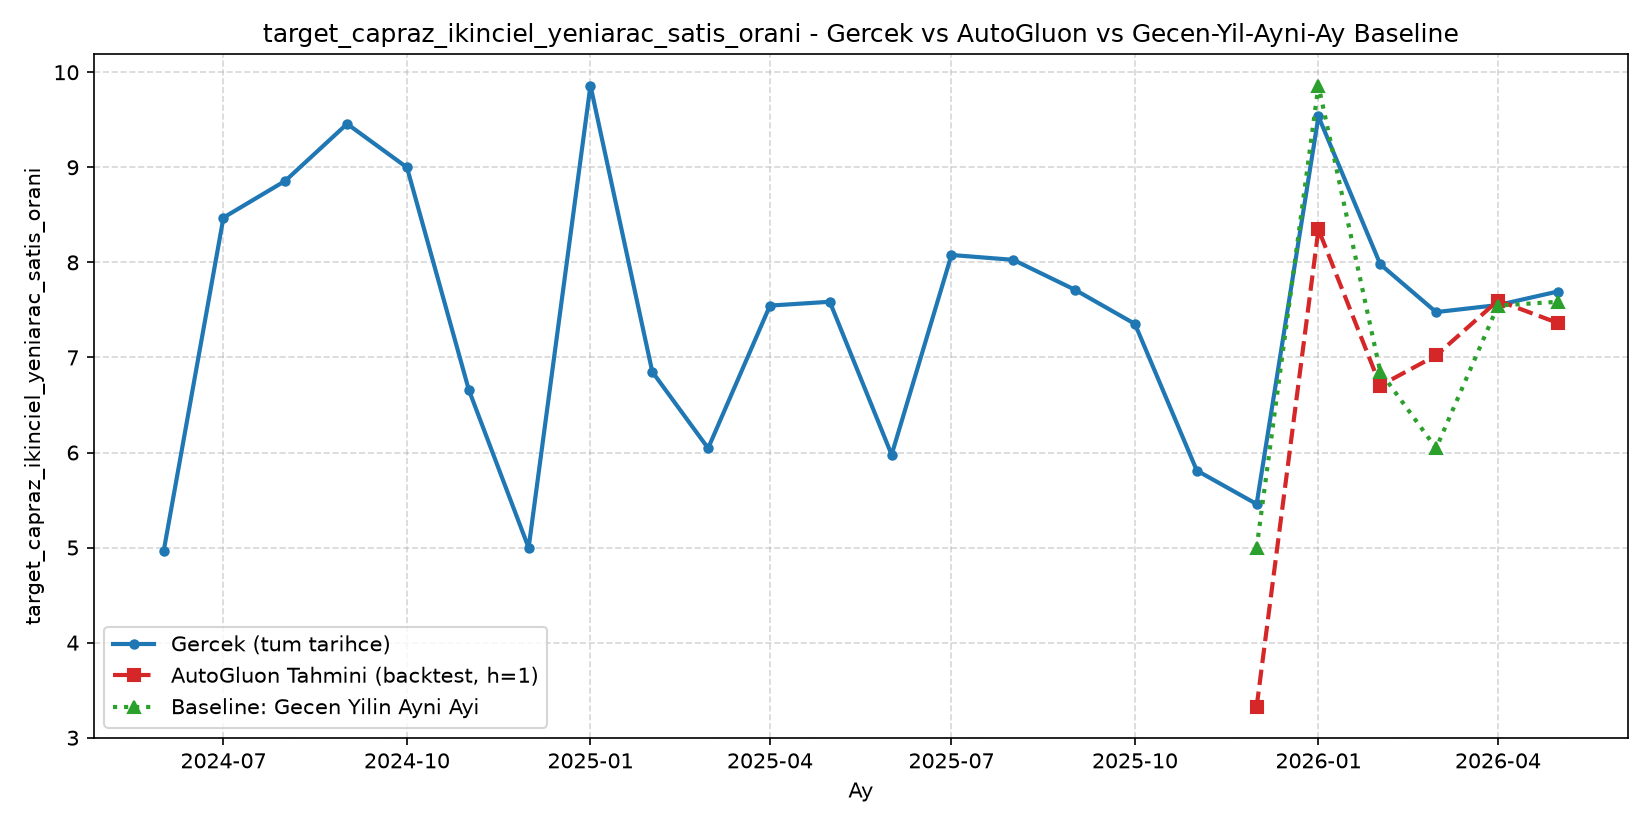

In [10]:
metrik_tablosu = pd.DataFrame(
    {
        "Model": sonuc["model_metrikleri"],
        "Baseline (t-12)": sonuc["baseline_metrikleri_gecen_yil_ayni_ay"],
    }
).T[["yon_dogrulugu", "mae", "rmse", "mase", "smape_pct", "bias", "n_test_ay"]]

display(metrik_tablosu)
display(backtest_df)
display(final_features)

grafik_yolu = OUT_DIR / "tahmin_grafigi.png"
if grafik_yolu.exists():
    display(Image(filename=str(grafik_yolu)))

## 11. Bilinen sınırlamalar

- **Bu çalıştırmada baseline, modelin tüm 6 metrikte önünde.** "Geçen yılın aynı ayı" (t-12) naive
  baseline'ı yön doğruluğunda %100 (6/6) tutarken model %83.3 (5/6) kaldı; mutlak hata
  metriklerinde de baseline daha iyi: MAE 0.58 vs 0.91, RMSE 0.78 vs 1.15, MASE 0.124 vs 0.195,
  sMAPE %8.35 vs %15.09. İkisi de negatif bias taşıyor (model −0.89, baseline −0.47) — yani her
  ikisi de oranı sistematik olarak hafif düşük tahmin ediyor, model daha belirgin biçimde.
- **AutoGluon'un `medium_quality` preset'i sabit random seed kullanmadığından ve backtest
  örneklemi küçük (n=6) olduğundan**, bu hedefte de yeniden çalıştırmalar arasında sonuçların
  (özellikle yön doğruluğunda) belirgin şekilde değişebildiği bu projede daha önce gözlemlenmiş
  bir bulgudur; tek bir çalıştırmadaki "kazanan" yorumu ihtiyatla okunmalı — burada baseline'ın
  üstünlüğü de kalıcı bir sonuç olmak zorunda değil, bu çalıştırmaya özgü bir gözlem olabilir.
- Fold başına en iyi model çoğunlukla `WeightedEnsemble` (4/6 fold), ayrıca birer kez
  `RecursiveTabular` ve `Toto2` seçildi — model seçiminin fold'lar arasında istikrarsız olması da
  küçük örneklemin bir başka belirtisi.
- Örneklem 101 ay olsa da (2018-01 → 2026-05), backtest yalnızca son 6 ayı kapsıyor; tek bir
  yanlış/doğru yön tahmini, yön doğruluğunu ~%17 oynatıyor.
- Oran hem `noter_devir_otomobil_adet` hem `odmd_otomobil_adet`'in pay/payda dinamiklerine bağlı
  olduğundan, iki seriden birindeki tek aylık bir anomali (ör. ÖTV değişikliği öncesi stoklama,
  resmi tatil kaynaklı düşük tescil) oranı büyük sıçratabilir — model bu tür payda-kaynaklı
  gürültüyü, bu çalıştırmada en azından, baseline'dan daha iyi ayıklayamamış görünüyor.